# Module 4 Homework: KNN Classification, Factor Analysis & Conjoint Analysis

This homework covers the concepts from **Module 4.0 (k-NN)** and **Module 4.1 (Factor Analysis & Conjoint Analysis)**.

**Instructions:**
- Write your code in the provided empty code cells
- Use the **exact variable names** specified in each question
- Your outputs should match the descriptions provided

---

# Part 1: k-NN Classification — Loan Default Prediction

**Dataset:** `Loan_default.csv`

A bank wants to predict which borrowers will **default** on their loans. You will build a k-NN classifier using borrower characteristics.

**Target variable:** `Default` (0 = no default, 1 = default)

### Q1: Load Libraries

Load the following libraries:
- `caret`
- `ggplot2`

In [5]:
library(caret)
library(ggplot2)

### Q2: Load and Explore the Data

Load the loan default dataset and prepare it for analysis.

- Store the data in **`loan.df`**
- Remove the `LoanID` column (not a predictor)
- Convert `Default` to a factor with labels `"No"` and `"Yes"`

**Expected output:** `str()` should show numeric columns (Age, Income, LoanAmount, CreditScore, MonthsEmployed, NumCreditLines, InterestRate, LoanTerm, DTIRatio), character/factor columns (Education, EmploymentType, MaritalStatus, HasMortgage, HasDependents, LoanPurpose, HasCoSigner), and Default as a Factor with 2 levels.

In [6]:
loan.df <- read.csv("Loan_default.csv")
loan.df$LoanID <- NULL
loan.df$Default <- factor(loan.df$Default,
levels = c(0,1),
labels = c("No","Yes"))
str(loan.df)

'data.frame':	255347 obs. of  17 variables:
 $ Age           : int  56 69 46 32 60 25 38 56 36 40 ...
 $ Income        : int  85994 50432 84208 31713 20437 90298 111188 126802 42053 132784 ...
 $ LoanAmount    : int  50587 124440 129188 44799 9139 90448 177025 155511 92357 228510 ...
 $ CreditScore   : int  520 458 451 743 633 720 429 531 827 480 ...
 $ MonthsEmployed: int  80 15 26 0 8 18 80 67 83 114 ...
 $ NumCreditLines: int  4 1 3 3 4 2 1 4 1 4 ...
 $ InterestRate  : num  15.23 4.81 21.17 7.07 6.51 ...
 $ LoanTerm      : int  36 60 24 24 48 24 12 60 48 48 ...
 $ DTIRatio      : num  0.44 0.68 0.31 0.23 0.73 0.1 0.16 0.43 0.2 0.33 ...
 $ Education     : chr  "Bachelor's" "Master's" "Master's" "High School" ...
 $ EmploymentType: chr  "Full-time" "Full-time" "Unemployed" "Full-time" ...
 $ MaritalStatus : chr  "Divorced" "Married" "Divorced" "Married" ...
 $ HasMortgage   : chr  "Yes" "No" "Yes" "No" ...
 $ HasDependents : chr  "Yes" "No" "Yes" "No" ...
 $ LoanPurpose   : chr  "Othe

### Q3: Select Numeric Features

Create a data frame called **`knn.df`** containing only these columns from `loan.df`:

- `Age`, `Income`, `LoanAmount`, `CreditScore`, `MonthsEmployed`, `InterestRate`, `DTIRatio`, `Default`

**Expected output:** A data frame with 8 columns — 7 numeric predictors and the Default factor.

In [7]:
knn.df <- loan.df[, c("Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",  "InterestRate", "DTIRatio", "Default")]
str(knn.df)

'data.frame':	255347 obs. of  8 variables:
 $ Age           : int  56 69 46 32 60 25 38 56 36 40 ...
 $ Income        : int  85994 50432 84208 31713 20437 90298 111188 126802 42053 132784 ...
 $ LoanAmount    : int  50587 124440 129188 44799 9139 90448 177025 155511 92357 228510 ...
 $ CreditScore   : int  520 458 451 743 633 720 429 531 827 480 ...
 $ MonthsEmployed: int  80 15 26 0 8 18 80 67 83 114 ...
 $ InterestRate  : num  15.23 4.81 21.17 7.07 6.51 ...
 $ DTIRatio      : num  0.44 0.68 0.31 0.23 0.73 0.1 0.16 0.43 0.2 0.33 ...
 $ Default       : Factor w/ 2 levels "No","Yes": 1 1 2 1 1 2 1 1 2 1 ...


### Q4: Split Data into Training and Holdout Sets

Split `knn.df` into training and holdout sets.

- Use `set.seed(42)`
- **60/40** split
- Store the training set in **`train.df`** and the holdout set in **`holdout.df`**

**Expected output:** Print the number of observations in each set.

In [8]:
set.seed(42)
trainIndex <- createDataPartition(knn.df$Default, p = 0.6, list = FALSE)
train.df <- knn.df[trainIndex, ]
holdout.df <- knn.df[-trainIndex, ]
nrow(train.df)
nrow(holdout.df)

[1] 153209

[1] 102138

### Q5: Train a k-NN Model with k=5

Train a k-NN model predicting `Default` from all other columns in `train.df`.

- Use **k = 5**
- **Normalize** the features (center and scale)
- Store the result in **`model`**

**Expected output:** Model summary showing k-Nearest Neighbors, the number of samples, predictors, classes, and that pre-processing was applied.

In [9]:
model <- train(
  Default ~ .,
  data = train.df,
  method = "knn",
  tuneGrid = data.frame(k = 5),
  preProcess = c("center", "scale"),
  trControl = trainControl(method = "none")
)

model

k-Nearest Neighbors 

153209 samples
     7 predictor
     2 classes: 'No', 'Yes' 

Pre-processing: centered (7), scaled (7) 
Resampling: None 

### Q6: Make Predictions on the Holdout Set

Classify the holdout set using your trained model. Store the predictions in **`predictions`**.

**Expected output:** Print the first 10 predictions — a vector of factor levels (`No` / `Yes`).

In [10]:
predictions <- predict(model, newdata = holdout.df)
head(predictions, 10)

[1] No No No No No No No No No No
Levels: No Yes

### Q7: Get Probability Predictions

Get class probability predictions on the holdout set. Store the result in **`probabilities`**.

**Expected output:** Print the first 10 rows — a data frame with two columns (`No` and `Yes`) showing the probability of each class.

In [11]:
probabilities <- predict(model, newdata = holdout.df[, names(holdout.df) != "Default"], type = "prob")
head(probabilities, 10)

,No,Yes
,<dbl>,<dbl>
1,1.0,0.0
2,0.8,0.2
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,1.0,0.0
7,0.6,0.4
8,1.0,0.0
9,0.8,0.2


### Q8: Tune k Using Cross-Validation

Tune the k-NN model using **5-fold cross-validation** to find the best k.

- Store the train control object in **`trControl`**
- Test `k = 1, 3, 5, 7, 9, 11, 13`
- Store the tuned model in **`model_tuned`**

**Expected output:** A table showing accuracy for each tested k value, with the best k highlighted.

### Q9: Train Final Model with Best k

Train a final model on **all of `knn.df`** using the best k from Q8. Store it in **`final_model`**.

**Expected output:** Model summary trained on the full dataset with the optimal k value.

In [ ]:
final_model <- train(
  Default ~ .,
  data = knn.df,
  method = "knn",
  tuneGrid = data.frame(k = 5),
  preProcess = c("center", "scale")
)

final_model

Installing package into ‘/home/jovyan/R/library’
(as ‘lib’ is unspecified)



---

# Part 2: Factor Analysis

**Dataset:** `Factor-Analysis-Example.csv`

This dataset contains survey responses where respondents rated an instructor on 9 attributes (1–10 scale):
**Expect**, **Entertain**, **Comm**, **Expert**, **Motivate**, **Caring**, **Charisma**, **Passion**, **Friendly**

Your goal is to discover the hidden factors underlying these ratings.

### Q10: Load Libraries

Load the following libraries:
- `psych`
- `corrplot`

In [2]:
install.packages("psych")
install.packages("corrplot")

# Load libraries
library(psych)
library(corrplot)

Installing package into ‘/home/jovyan/R/library’
(as ‘lib’ is unspecified)



Installing package into ‘/home/jovyan/R/library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



### Q11: Load and Explore the Data

Load the factor analysis dataset and store it in **`fa_data`**.

**Note:** This CSV may have extra empty columns. If so, keep only the first 9 columns (Expect through Friendly).

**Expected output:** `str()` should show 9 numeric variables and approximately 125 observations.

In [3]:
fa_data <- read.csv("Factor-Analysis-Example.csv")
fa_data <- fa_data[, 1:9]

str(fa_data)

'data.frame':	126 obs. of  9 variables:
 $ Expect   : chr  "2" "4" "2" "4" ...
 $ Entertain: chr  "8" "8" "8" "8" ...
 $ Comm     : chr  "1" "5" "2" "4" ...
 $ Expert   : chr  "4" "3" "3" "2" ...
 $ Motivate : chr  "7" "7" "6" "8" ...
 $ Caring   : chr  "5" "7" "7" "7" ...
 $ Charisma : chr  "4" "7" "1" "7" ...
 $ Passion  : chr  "4" "6" "3" "5" ...
 $ Friendly : chr  "8" "6" "7" "7" ...


### Q12: Correlation Matrix and Heatmap

Compute the correlation matrix of `fa_data` and store it in **`cor_matrix`**. Then visualize it as a heatmap.

**Expected output:** A heatmap showing pairwise correlations between all 9 variables with correlation coefficients displayed. Look for blocks of variables that correlate strongly with each other.

Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


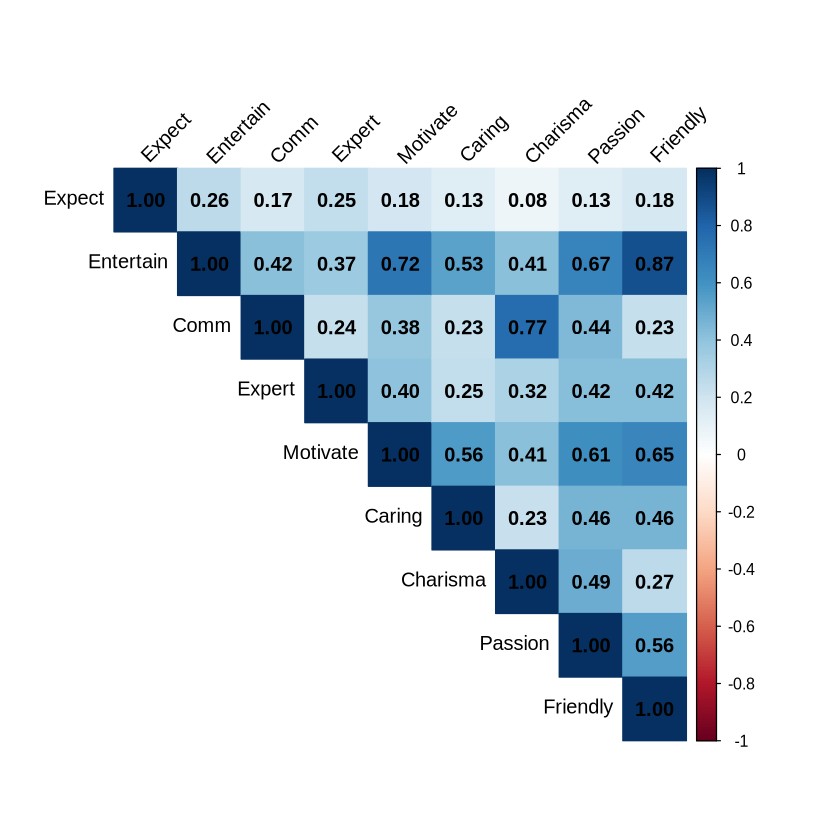

In [7]:
fa_data <- read.csv("Factor-Analysis-Example.csv", stringsAsFactors = FALSE)
fa_data <- fa_data[, 1:9]
fa_data <- data.frame(lapply(fa_data, function(x) as.numeric(as.character(x))))
fa_data <- na.omit(fa_data)
cor_matrix <- cor(fa_data)
corrplot(cor_matrix,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         tl.col = "black",
         tl.srt = 45)

### Q13: KMO and Bartlett's Tests

Run the KMO test and Bartlett's test of sphericity to verify that the data is suitable for factor analysis.

- Store the KMO result in **`kmo_result`**
- Store the Bartlett's result in **`bartlett_result`**

**Expected output:** Print the overall KMO MSA value (check if ≥ 0.60), and the Bartlett's chi-square value and p-value (check if p < 0.05). Both must pass to proceed.

In [8]:
kmo_result <- KMO(fa_data)
bartlett_result <- cortest.bartlett(cor(fa_data), n = nrow(fa_data))
kmo_result
bartlett_result

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = fa_data)
Overall MSA =  0.79
MSA for each item = 
   Expect Entertain      Comm    Expert  Motivate    Caring  Charisma   Passion 
     0.60      0.74      0.70      0.77      0.93      0.91      0.72      0.91 
 Friendly 
     0.73 

$chisq
[1] 606.3294

$p.value
[1] 9.992734e-105

$df
[1] 36

### Q14: Parallel Analysis

Run a parallel analysis on `fa_data` to determine the number of factors to extract.

**Expected output:** A scree plot and a text message suggesting the number of factors. Record this number — you will use it in Q15.

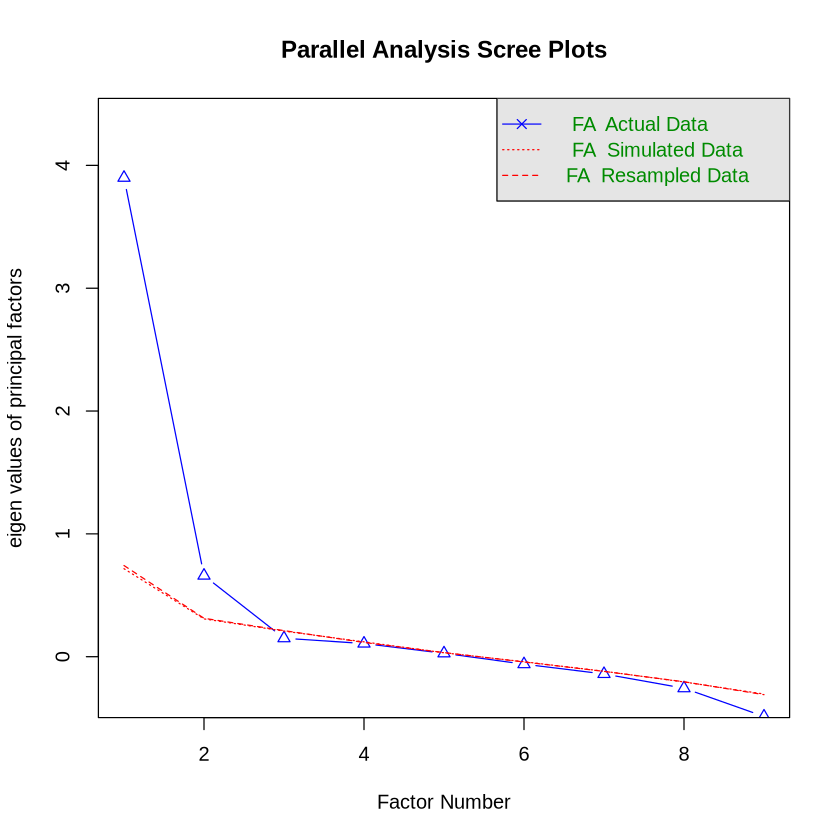

In [11]:
fa.parallel(fa_data, fa = "fa", n.iter = 100)

### Q15: Extract Factors with Varimax Rotation

Extract factors from `fa_data` using **varimax rotation** with the number of factors suggested by Q14. Store the result in **`fa_result`**.

Print the loadings with a cutoff of **0.3** (sorted).

**Expected output:** A factor loadings table showing which variables load on which factors. Values below 0.3 are hidden for clarity.

In [12]:
fa_result <- fa(fa_data, nfactors = 2, rotate = "varimax")
print(fa_result$loadings, cutoff = 0.3, sort = TRUE)


Loadings:
          MR1   MR2  
Entertain 0.901      
Motivate  0.763      
Caring    0.582      
Passion   0.648 0.391
Friendly  0.868      
Comm            0.786
Charisma        0.908
Expect               
Expert    0.434      

                 MR1   MR2
SS loadings    3.246 1.810
Proportion Var 0.361 0.201
Cumulative Var 0.361 0.562


### Q16: Factor Diagram

Create a visual diagram of the factor structure from `fa_result`.

**Expected output:** A diagram with ovals (factors) connected by arrows to rectangles (variables). Thicker arrows indicate stronger factor loadings.

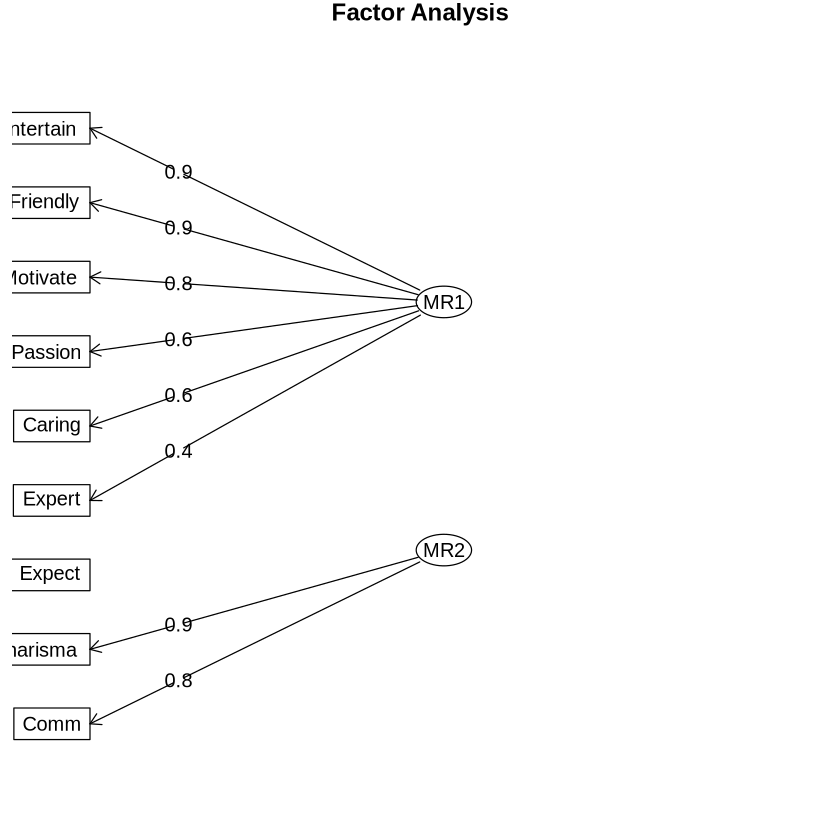

In [13]:
fa.diagram(fa_result)

### Q17: Cronbach's Alpha

Based on the factor loadings from Q15, identify which variables belong to each factor. Pick **one** of your factors and compute Cronbach's Alpha for those variables.

- Store the result in **`alpha_result`**

**Expected output:** Print the raw alpha value. Check if it is ≥ 0.70 (acceptable reliability).

In [15]:
factor_vars <- fa_data[, c("Friendly", "Caring", "Charisma", "Passion")]
alpha_result <- alpha(factor_vars)
alpha_result$total$raw_alpha

Number of categories should be increased  in order to count frequencies. 



[1] 0.6513044

---

# Part 3: Conjoint Analysis

**Dataset:** `pizza_data.csv`

A pizza company wants to understand which product features drive customer preference. Respondents ranked 16 different pizza profiles (1 = most preferred, 16 = least preferred).

**Attributes:** `crust`, `cheese`, `size`, `toppings`, `spicy`

**Preference variable:** `ranking`

### Q18: Load the Data

Load the pizza conjoint dataset and store it in **`pizza.df`**.

**Expected output:** A data frame with 16 rows and 9 columns showing all pizza profiles and their rankings.

In [16]:
pizza.df <- read.csv("pizza_data.csv")
str(pizza.df)
head(pizza.df)

'data.frame':	16 obs. of  9 variables:
 $ brand   : chr  "Dominos" "Pizza hut" "Onesta" "Pizza hut" ...
 $ price   : chr  "$1.00" "$3.00" "$4.00" "$4.00" ...
 $ weight  : chr  "100g" "100g" "200g" "400g" ...
 $ crust   : chr  "thin" "thin" "thin" "thick" ...
 $ cheese  : chr  "Mozzarella" "Cheddar" "Mozzarella" "Cheddar" ...
 $ size    : chr  "regular" "large" "regular" "regular" ...
 $ toppings: chr  "paneer" "mushroom" "mushroom" "paneer" ...
 $ spicy   : chr  "normal" "normal" "normal" "normal" ...
 $ ranking : int  11 12 9 2 8 13 7 4 5 16 ...


,brand,price,weight,crust,cheese,size,toppings,spicy,ranking
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,Dominos,$1.00,100g,thin,Mozzarella,regular,paneer,normal,11
2,Pizza hut,$3.00,100g,thin,Cheddar,large,mushroom,normal,12
3,Onesta,$4.00,200g,thin,Mozzarella,regular,mushroom,normal,9
4,Pizza hut,$4.00,400g,thick,Cheddar,regular,paneer,normal,2
5,Pizza hut,$2.00,300g,thin,Mozzarella,regular,mushroom,extra,8
6,Pizza hut,$1.00,200g,thick,Mozzarella,large,paneer,extra,13


### Q19: Regression-Based Conjoint Analysis

Fit a linear regression predicting `ranking` from `crust`, `cheese`, `size`, `toppings`, and `spicy`. Store the model in **`pizza_model`**.

**Expected output:** A regression summary where each coefficient is a **part-worth utility** showing how much each feature level changes the ranking relative to the reference level. Check which coefficients are significant (p < 0.05).

In [17]:
pizza.df$crust <- as.factor(pizza.df$crust)
pizza.df$cheese <- as.factor(pizza.df$cheese)
pizza.df$size <- as.factor(pizza.df$size)
pizza.df$toppings <- as.factor(pizza.df$toppings)
pizza.df$spicy <- as.factor(pizza.df$spicy)
pizza_model <- lm(ranking ~ crust + cheese + size + toppings + spicy, data = pizza.df)
summary(pizza_model)


Call:
lm(formula = ranking ~ crust + cheese + size + toppings + spicy, 
    data = pizza.df)

Residuals:
   Min     1Q Median     3Q    Max 
-6.375 -2.688  0.375  3.312  5.625 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)   
(Intercept)        11.625      3.121   3.725  0.00394 **
crustthin          -3.500      2.548  -1.373  0.19961   
cheeseMozzarella    0.500      2.548   0.196  0.84838   
sizeregular         0.500      2.548   0.196  0.84838   
toppingspaneer     -2.250      2.548  -0.883  0.39799   
spicynormal        -1.500      2.548  -0.589  0.56916   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.097 on 10 degrees of freedom
Multiple R-squared:  0.236,	Adjusted R-squared:  -0.146 
F-statistic: 0.6179 on 5 and 10 DF,  p-value: 0.6897


### Q20: Visualize Mean Ranking by Attribute

Create bar plots showing the **mean ranking** for each level of at least **three** of the five attributes (`crust`, `cheese`, `size`, `toppings`, `spicy`).

**Expected output:** Bar charts where the height of each bar is the average ranking for that attribute level. **Remember:** lower ranking = more preferred, so shorter bars indicate higher preference.


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




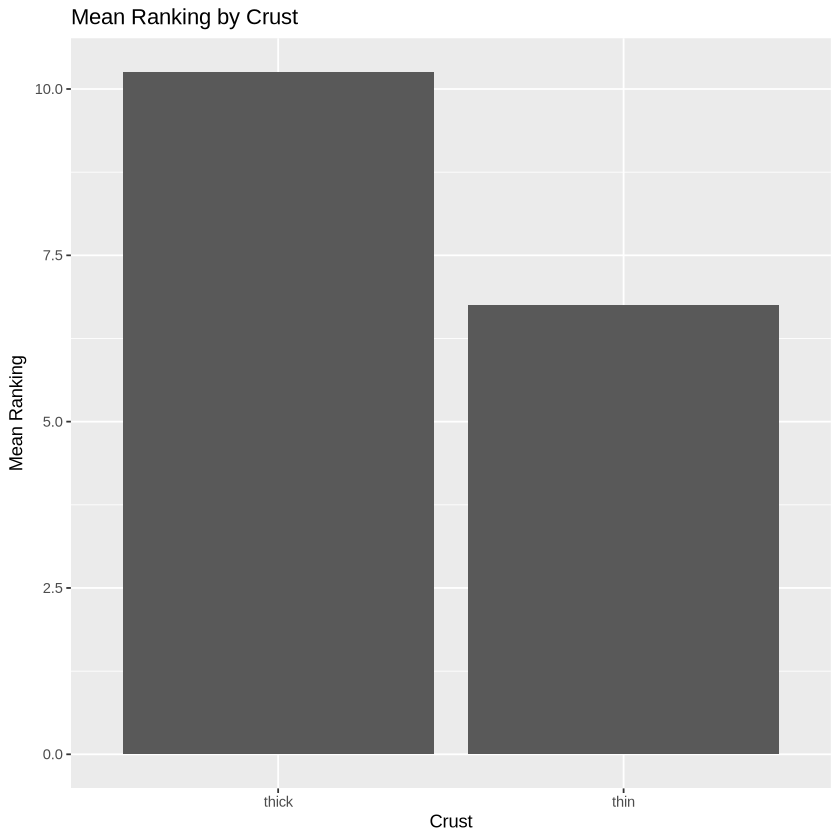

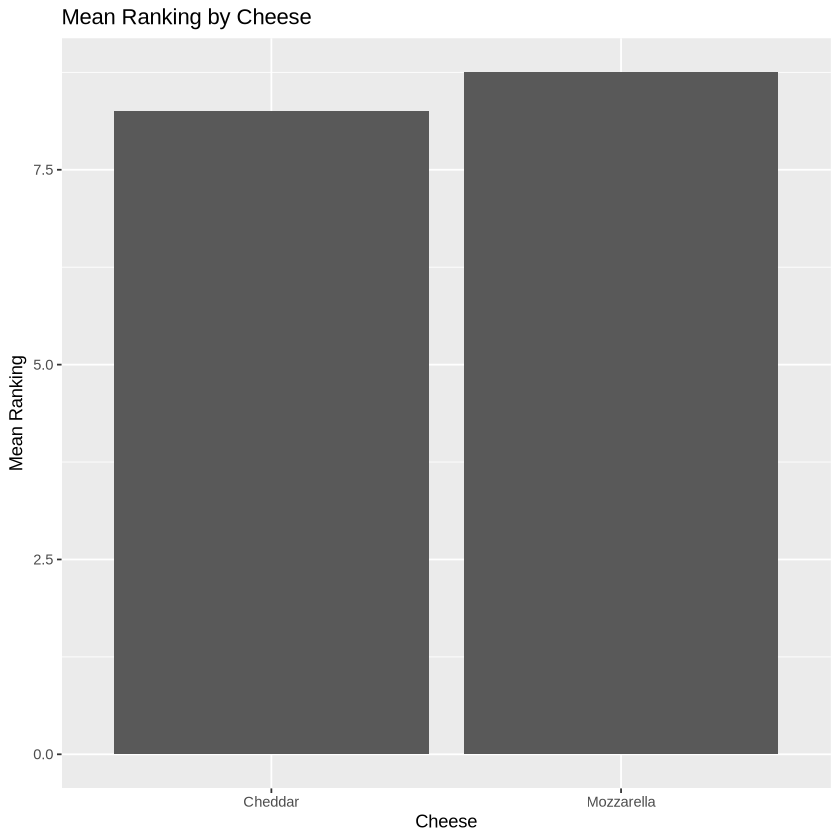

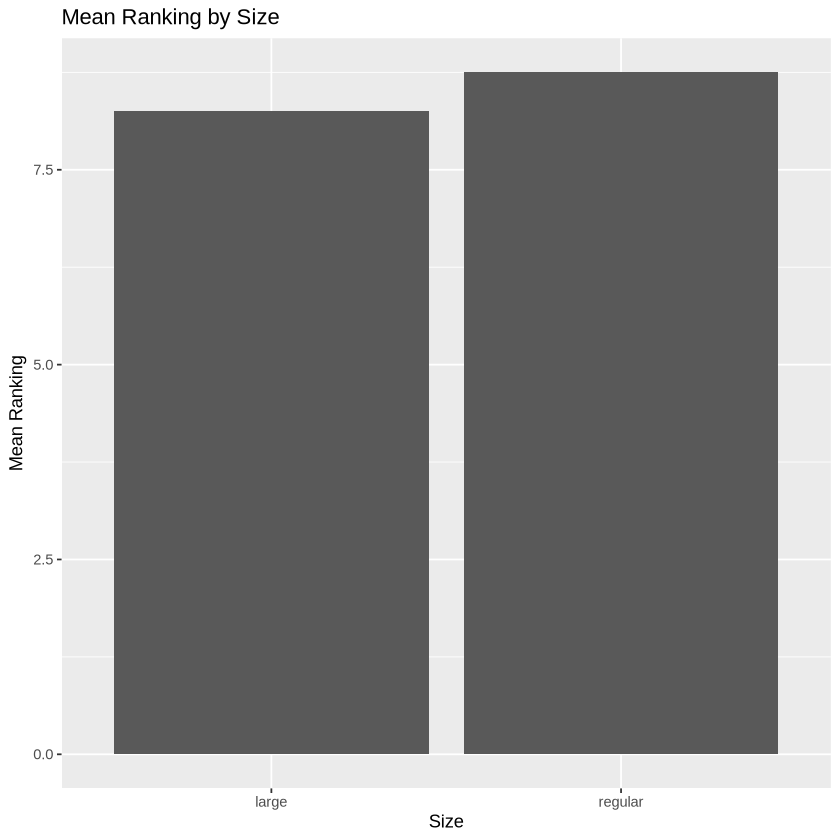

In [18]:
library(ggplot2)
library(dplyr)
crust_avg <- pizza.df %>%
  group_by(crust) %>%
  summarise(mean_ranking = mean(ranking))

ggplot(crust_avg, aes(x = crust, y = mean_ranking)) +
  geom_bar(stat = "identity") +
  ggtitle("Mean Ranking by Crust") +
  ylab("Mean Ranking") +
  xlab("Crust")

cheese_avg <- pizza.df %>%
  group_by(cheese) %>%
  summarise(mean_ranking = mean(ranking))

ggplot(cheese_avg, aes(x = cheese, y = mean_ranking)) +
  geom_bar(stat = "identity") +
  ggtitle("Mean Ranking by Cheese") +
  ylab("Mean Ranking") +
  xlab("Cheese")

size_avg <- pizza.df %>%
  group_by(size) %>%
  summarise(mean_ranking = mean(ranking))

ggplot(size_avg, aes(x = size, y = mean_ranking)) +
  geom_bar(stat = "identity") +
  ggtitle("Mean Ranking by Size") +
  ylab("Mean Ranking") +
  xlab("Size")